In [13]:
import pandas as pd
from matplotlib import pyplot as plt

In [11]:
df = pd.read_csv(r"Data\tagesschau_zdf_pbs_foxnews_bild_gkg_partitioned_full.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 292678 entries, 0 to 292677
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   DATE              292678 non-null  int64
 1   SourceCommonName  292678 non-null  str  
 2   url               292678 non-null  str  
 3   V2Persons         161101 non-null  str  
 4   V2Organizations   217726 non-null  str  
 5   V2Tone            292678 non-null  str  
dtypes: int64(1), str(5)
memory usage: 13.4 MB


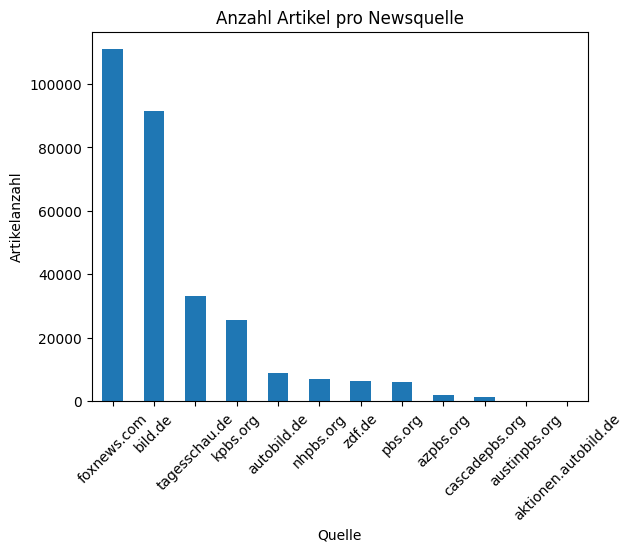

In [14]:


df["SourceCommonName"].value_counts().plot(kind="bar")

plt.title("Anzahl Artikel pro Newsquelle")
plt.xlabel("Quelle")
plt.ylabel("Artikelanzahl")
plt.xticks(rotation=45)
plt.show()

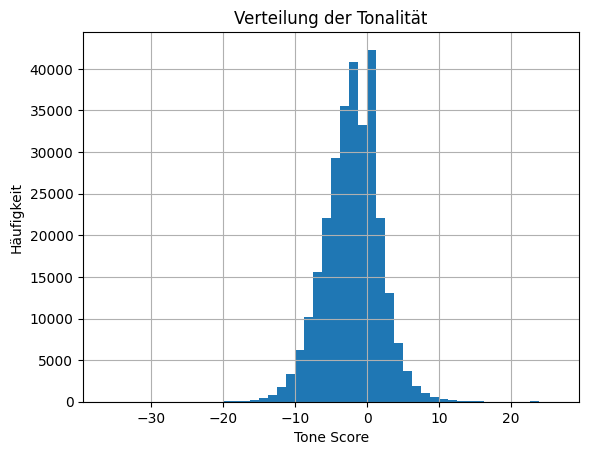

In [19]:
df["tone"] = df["V2Tone"].str.split(",").str[0].astype(float)

df["tone"].hist(bins=50)

plt.title("Verteilung der Tonalität")
plt.xlabel("Tone Score")
plt.ylabel("Häufigkeit")
plt.show()

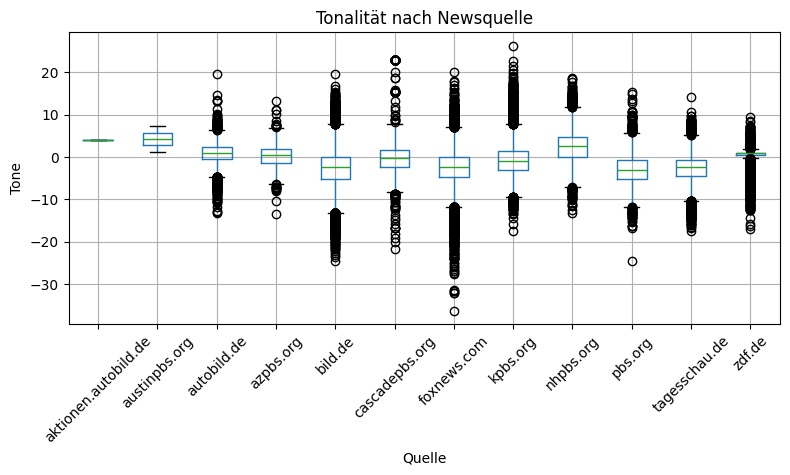

In [29]:
df.boxplot(column="tone", by="SourceCommonName", figsize=(8,5))

plt.title("Tonalität nach Newsquelle")
plt.suptitle("")
plt.xlabel("Quelle")
plt.ylabel("Tone")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

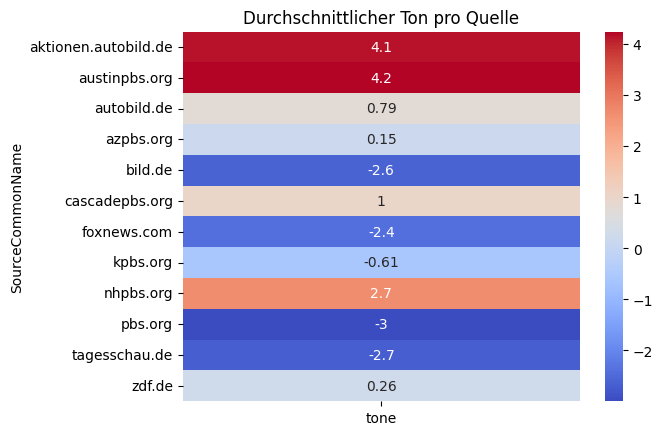

In [28]:
import seaborn as sns

pivot = df.groupby("SourceCommonName")["tone"].mean().to_frame()

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Durchschnittlicher Ton pro Quelle")
plt.show()

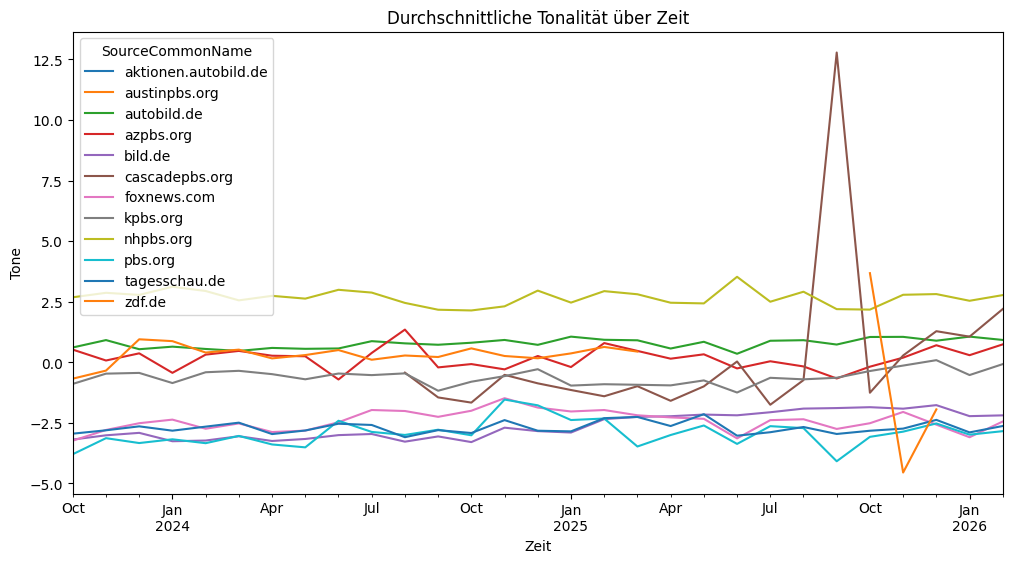

In [30]:
df["month"] = df["DATE"].dt.to_period("M")
tone_time = df.groupby(["month","SourceCommonName"])["tone"].mean().unstack()

tone_time.plot(figsize=(12,6))

plt.title("Durchschnittliche Tonalität über Zeit")
plt.ylabel("Tone")
plt.xlabel("Zeit")
plt.show()

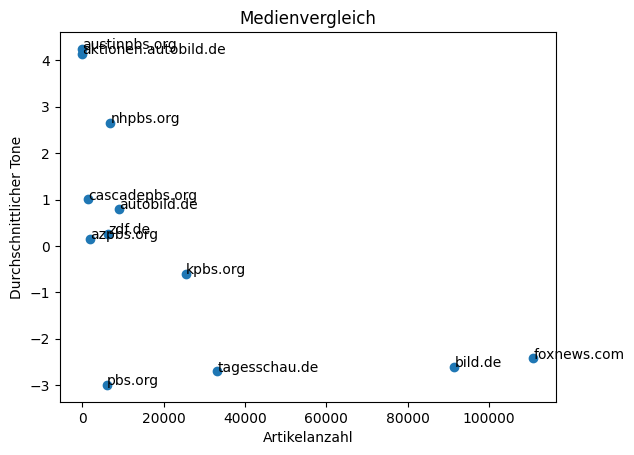

In [31]:
stats = df.groupby("SourceCommonName").agg({
    "tone":"mean",
    "url":"count"
})

plt.scatter(stats["url"], stats["tone"])

for i in stats.index:
    plt.text(stats.loc[i,"url"], stats.loc[i,"tone"], i)

plt.xlabel("Artikelanzahl")
plt.ylabel("Durchschnittlicher Tone")
plt.title("Medienvergleich")
plt.show()